<a href="https://colab.research.google.com/github/mohamadfaisalbashir/scikit-learn-cookbook/blob/main/05_Linear_Models_and_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Linear Models and Regularization**

This notebook covers Linear Models and Regularization.

1. Introduction to Linear Models
2. Ridge and Lasso Regression
3. ElasticNet and Regularization
4. Regularization Theory and Practice
5. Regression and Regularization (Polynomial & Spline)

# **1. Introduction to Linear Models**

Linear regression is likely the first predictive model most practitioners encounter — and for good reason. At its core, it seeks a mathematical relationship between one or more input features and a continuous target variable, represented by the equation of a line. The simplest form is **Ordinary Least Squares (OLS)** regression.

## **1.1 Conceptual Foundation**

The linear regression equation is expressed as:

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n + \epsilon$$

Where:
- $y$ is the predicted (target) value  
- $\beta_0$ is the intercept  
- $\beta_n$ are the feature coefficients  
- $x_n$ are the feature values  
- $\epsilon$ is the error (residual) term

The model learns coefficients $\beta$ by minimizing the **sum of squared residuals** between predictions and actual values on the training set.

## **1.2 Synthetic Dataset Setup**

The chapter uses `make_regression()` to construct a controlled synthetic dataset with:
- 1,000 samples and 100 features (only 10 are truly informative)
- Added **multicollinearity** (50 features are correlated with another 50)
- Non-linearity injected into the target via a sine wave and exponential term

This setup deliberately mirrors the messy conditions encountered in real datasets — making it ideal for demonstrating where plain OLS begins to struggle.

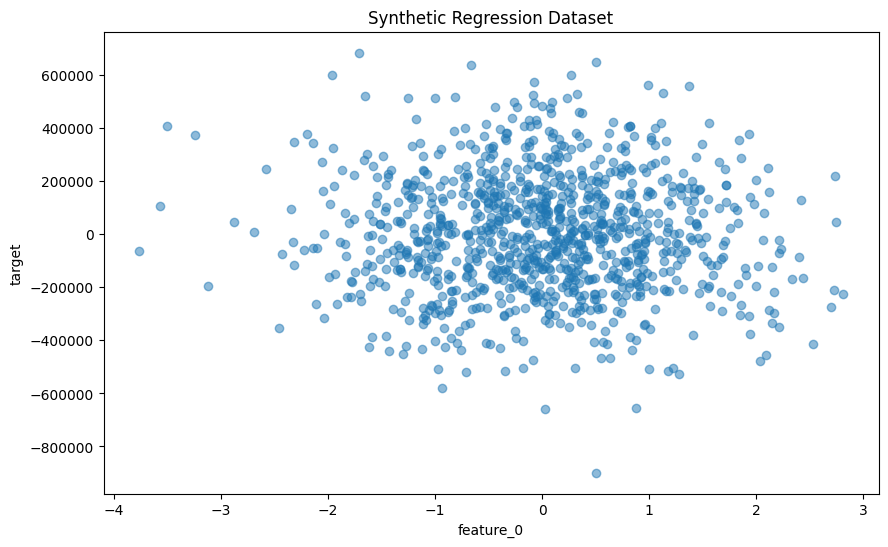

Dataset shape: (1000, 101)


In [1]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

np.random.seed(123)

# Create a synthetic regression dataset with multicollinearity
X, y = make_regression(
    n_samples=1000,
    n_features=100,
    n_informative=10,
    noise=20,
    random_state=123
)

# Inject multicollinearity: half the features are correlated with the other half
for i in range(50, 100):
    X[:, i] = X[:, i - 50] + np.random.normal(0, 0.1, size=1000)

feature_names = [f'feature_{i}' for i in range(100)]
X_plot = X[:, 0].reshape(-1, 1)

# Add non-linearity to the target
y = y * 1000
y = (y + np.sin(X_plot.ravel()) * 150 + np.exp(X_plot.ravel() / 10))

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Quick visualization
plt.figure(figsize=(10, 6))
plt.scatter(X_plot, y, alpha=0.5)
plt.xlabel('feature_0')
plt.ylabel('target')
plt.title('Synthetic Regression Dataset')
plt.show()

print(f"Dataset shape: {df.shape}")


## **1.3 Training a Linear Regression Model**

With the dataset prepared, fitting a linear regression model in scikit-learn is straightforward. The model is evaluated using two standard metrics:

- **Mean Squared Error (MSE):** measures average squared prediction error — lower is better
- **R² (Coefficient of Determination):** measures how much variance in the target is explained by the model — closer to 1.0 is better

Mean Squared Error : 46,550,591,070.53
R-squared          : 0.0648


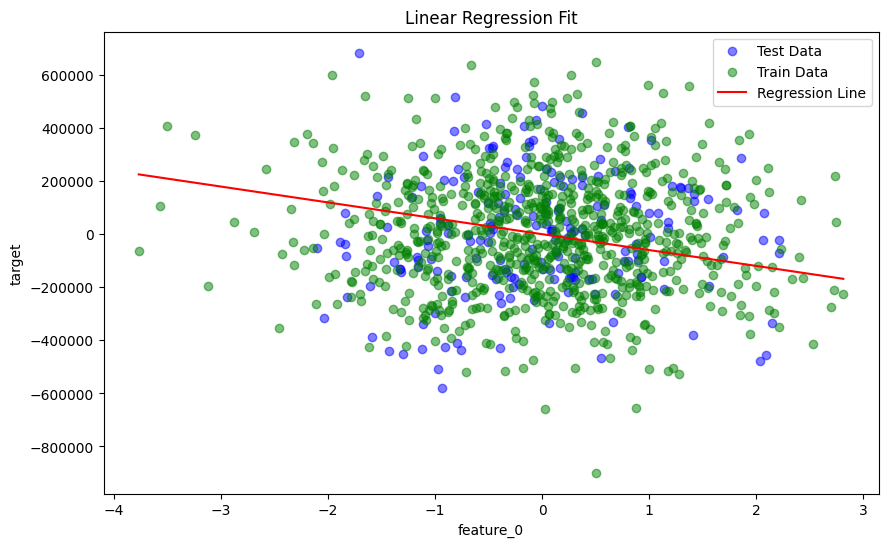

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

# Fit the model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = linear_model.predict(X_test)
mse  = mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"Mean Squared Error : {mse:,.2f}")
print(f"R-squared          : {r2:.4f}")

# Visualize the fit against training and test data
X_line = np.linspace(df['feature_0'].min(), df['feature_0'].max(), 100).reshape(-1, 1)
X_line_full = np.zeros((100, len(feature_names)))
X_line_full[:, 0] = X_line.ravel()
y_line = linear_model.predict(pd.DataFrame(X_line_full, columns=feature_names))

plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.5, label='Test Data')
plt.scatter(X_train[:, 0], y_train, color='green', alpha=0.5, label='Train Data')
plt.plot(X_line, y_line, color='red', label='Regression Line')
plt.xlabel('feature_0')
plt.ylabel('target')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()


# **2. Ridge and Lasso Regression**

Plain OLS regression has no mechanism to prevent individual coefficients from growing arbitrarily large — a recipe for overfitting on noisy, high-dimensional data. **Regularization** addresses this by adding a penalty term to the loss function that discourages overly complex models.

## **2.1 Ridge Regression (L2 Regularization)**

Ridge regression appends an **L2 penalty** — the sum of squared coefficients — to the OLS loss:

$$\text{Loss}_{\text{Ridge}} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} \beta_j^2$$

- The hyperparameter $\alpha$ controls regularization strength  
- Higher $\alpha$ → coefficients are shrunk closer to zero  
- Importantly, **Ridge never sets coefficients to exactly zero** — all features remain in the model

## **2.2 Lasso Regression (L1 Regularization)**

Lasso regression appends an **L1 penalty** — the sum of absolute coefficient values:

$$\text{Loss}_{\text{Lasso}} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} |\beta_j|$$

- The key difference: the L1 penalty **can drive coefficients to exactly zero**, performing implicit feature selection  
- Lasso is ideal when the data likely contains many irrelevant features

## **2.3 When to Use Which**

| Situation | Recommended Method |
|---|---|
| All features are potentially relevant | Ridge |
| Many features are likely irrelevant | Lasso |
| High multicollinearity present | Ridge or ElasticNet |
| Need automatic feature selection | Lasso |

In [3]:
from sklearn.linear_model import Ridge, Lasso

# Ridge regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

# Lasso regression (higher alpha + more iterations for convergence)
lasso_model = Lasso(alpha=10.0, max_iter=10000, tol=0.001)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

# Compare metrics across all three models
metrics = {
    'Model': ['Ridge Regression', 'Lasso Regression', 'Linear Regression'],
    'Mean Squared Error': [
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso),
        mean_squared_error(y_test, y_pred)
    ],
    'R-squared': [
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred)
    ]
}

metrics_df = pd.DataFrame(metrics).sort_values('Mean Squared Error')
metrics_df['Mean Squared Error'] = metrics_df['Mean Squared Error'].map('{:,.2f}'.format)
metrics_df['R-squared'] = metrics_df['R-squared'].map('{:.4f}'.format)
print(metrics_df.to_string(index=False))


            Model Mean Squared Error R-squared
 Ridge Regression  45,341,091,794.40    0.0891
 Lasso Regression  46,377,111,017.93    0.0683
Linear Regression  46,550,591,070.53    0.0648


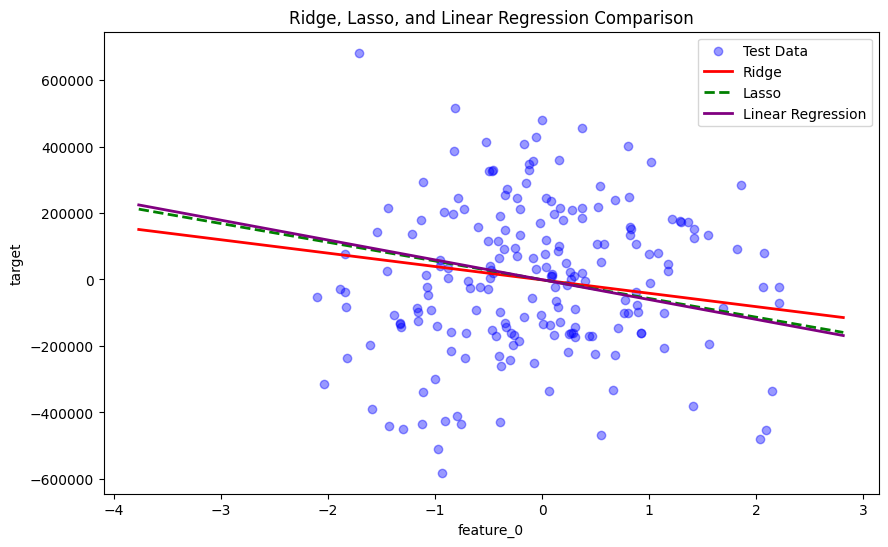

In [4]:
# Visual comparison of the three regression lines
X_line_df = pd.DataFrame(X_line_full, columns=feature_names)

y_line_ridge  = ridge_model.predict(X_line_df)
y_line_lasso  = lasso_model.predict(X_line_df)
y_line_linear = linear_model.predict(X_line_df)

plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.4, label='Test Data')
plt.plot(X_line, y_line_ridge,  color='red',    linewidth=2, label='Ridge')
plt.plot(X_line, y_line_lasso,  color='green',  linewidth=2, linestyle='--', label='Lasso')
plt.plot(X_line, y_line_linear, color='purple', linewidth=2, label='Linear Regression')
plt.xlabel('feature_0')
plt.ylabel('target')
plt.title('Ridge, Lasso, and Linear Regression Comparison')
plt.legend()
plt.show()


---
# **3. ElasticNet and Regularization**

**ElasticNet** is a hybrid regularization technique that combines both L1 (Lasso) and L2 (Ridge) penalties within a single loss function:

$$\text{Loss}_{\text{ElasticNet}} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \alpha \left( \lambda_1 \sum_{j=1}^{p} |\beta_j| + \lambda_2 \sum_{j=1}^{p} \beta_j^2 \right)$$

## **3.1 Key Hyperparameters**

| Parameter | Role |
|---|---|
| `alpha` | Overall regularization strength (higher = more shrinkage) |
| `l1_ratio` | Mix between L1 and L2 penalties (0 = pure Ridge, 1 = pure Lasso) |

## **3.2 Why ElasticNet?**

- When features are **highly correlated**, Lasso tends to arbitrarily select one and discard the rest. ElasticNet handles this more gracefully by distributing weight across correlated features.  
- It retains the **feature selection property** of Lasso (sparse coefficients) while benefiting from the **stability** of Ridge.  
- It is especially useful in datasets with **more predictors than observations** or when dealing with grouped features.

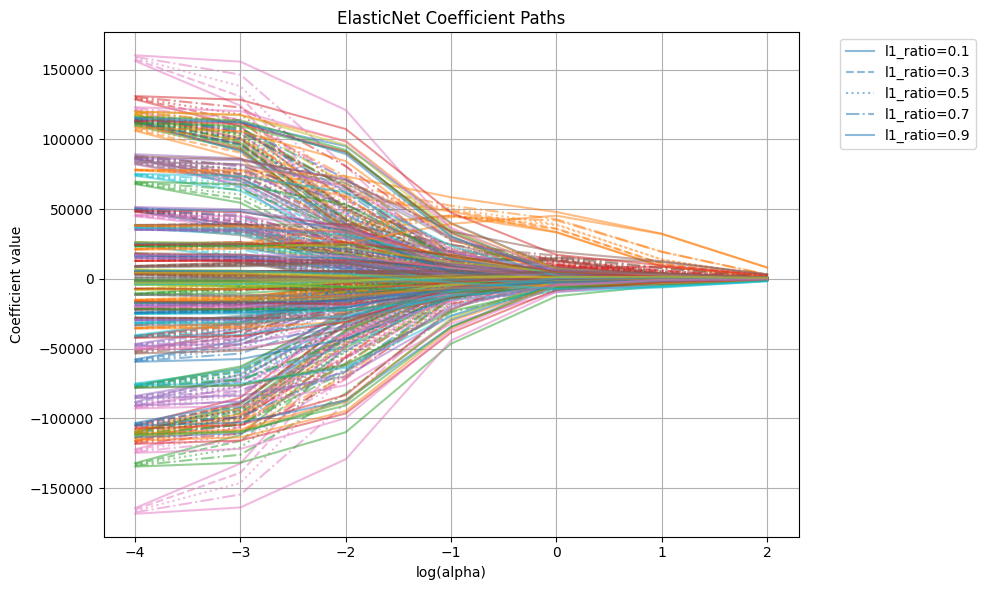

In [5]:
from sklearn.linear_model import ElasticNet

# Range of alpha and l1_ratio values to evaluate
alphas    = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
linestyles = ['solid', 'dashed', 'dotted', 'dashdot', '-']

plt.figure(figsize=(10, 6))

for idx, l1_ratio in enumerate(l1_ratios):
    coefs = []
    for alpha in alphas:
        model = ElasticNet(
            alpha=alpha, l1_ratio=l1_ratio,
            random_state=123, max_iter=10000, tol=1e-4
        )
        model.fit(X_train, y_train)
        coefs.append(model.coef_)

    for feature_idx in range(X_train.shape[1]):
        plt.plot(
            np.log10(alphas),
            np.array(coefs)[:, feature_idx],
            label=(f'l1_ratio={l1_ratio}' if feature_idx == 0 else ""),
            alpha=0.5,
            linestyle=linestyles[idx]
        )

plt.xlabel('log(alpha)')
plt.ylabel('Coefficient value')
plt.title('ElasticNet Coefficient Paths')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [6]:
# Fit a final ElasticNet model and compare against previous methods
elastic_model = ElasticNet(
    alpha=1.0, l1_ratio=0.5,
    random_state=123, max_iter=10000, tol=1e-4
)
elastic_model.fit(X_train, y_train)
elastic_pred  = elastic_model.predict(X_test)
elastic_mse   = mean_squared_error(y_test, elastic_pred)
elastic_r2    = r2_score(y_test, elastic_pred)

# Append to comparison table
new_row = pd.DataFrame({
    'Model': ['ElasticNet Regression'],
    'Mean Squared Error': [f'{elastic_mse:,.2f}'],
    'R-squared': [f'{elastic_r2:.4f}']
})
metrics_df = metrics_df[~metrics_df['Model'].str.contains('ElasticNet')]
metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)
print(metrics_df.to_string(index=False))


                Model Mean Squared Error R-squared
     Ridge Regression  45,341,091,794.40    0.0891
     Lasso Regression  46,377,111,017.93    0.0683
    Linear Regression  46,550,591,070.53    0.0648
ElasticNet Regression  42,616,635,365.79    0.1438


# **4. Regularization Theory and Practice**

Having seen regularization applied in code, it is worth stepping back to understand the underlying theory more carefully.

## **4.1 Why Regularization is Necessary**

Without regularization, a sufficiently flexible model can achieve near-perfect performance on training data by learning noise and idiosyncrasies specific to the training set. This is **overfitting** — the model memorizes rather than generalizes. The performance metric we ultimately care about is not training performance, but behavior on **new, unseen data**.

Regularization imposes constraints on model parameters, effectively pushing them toward zero (encouraging **sparsity**). This prevents the model from relying too heavily on any single feature.

## **4.2 Summary of Regularization Types**

| Method | Penalty Term | Effect on Coefficients | Feature Selection? |
|---|---|---|---|
| **Ridge (L2)** | $\alpha \sum \beta_j^2$ | Shrinks all toward zero, none become exactly zero | No |
| **Lasso (L1)** | $\alpha \sum |\beta_j|$ | Some become exactly zero | Yes |
| **ElasticNet** | Combination of L1 + L2 | Flexible — tuned by `l1_ratio` | Partial |

## **4.3 Bias-Variance Trade-Off**

Regularization directly manages the **bias-variance trade-off**:

- **Without regularization:** low bias, high variance → model fits training data well but is unstable on new data  
- **With regularization:** slightly higher bias, but significantly lower variance → more stable, generalizing predictions

The optimal regularization level minimizes **total prediction error on unseen data** — which is the true goal of any ML model.

# **5. Regression and Regularization — Polynomial & Spline Methods**

Not all real-world relationships between variables are linear. This section extends the linear regression framework to accommodate **non-linear patterns** through two complementary approaches.

## **5.1 Polynomial Regression**

**Polynomial regression** transforms input features into polynomial terms (e.g., $x^2$, $x^3$) before fitting a linear regression model. This allows the model to learn curved, non-linear relationships while still using the linear regression machinery.

$$y = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_n x^n + \epsilon$$

**Key consideration:** Higher polynomial degrees capture more complex patterns but risk **overfitting** — especially on noisy data. Evaluating with MSE and R² on a hold-out test set is essential to identify a reasonable degree.

## **5.2 Spline Interpolation**

**Spline interpolation** uses piecewise polynomials — fitting separate polynomial segments to different regions of the data, joined smoothly at boundary points called **knots**. scikit-learn provides `SplineTransformer` for this purpose.

Advantages over high-degree polynomial regression:
- More **local flexibility** — each segment adapts to its region
- Less prone to the wild oscillations that high-degree polynomials can produce
- The number of knots controls model complexity

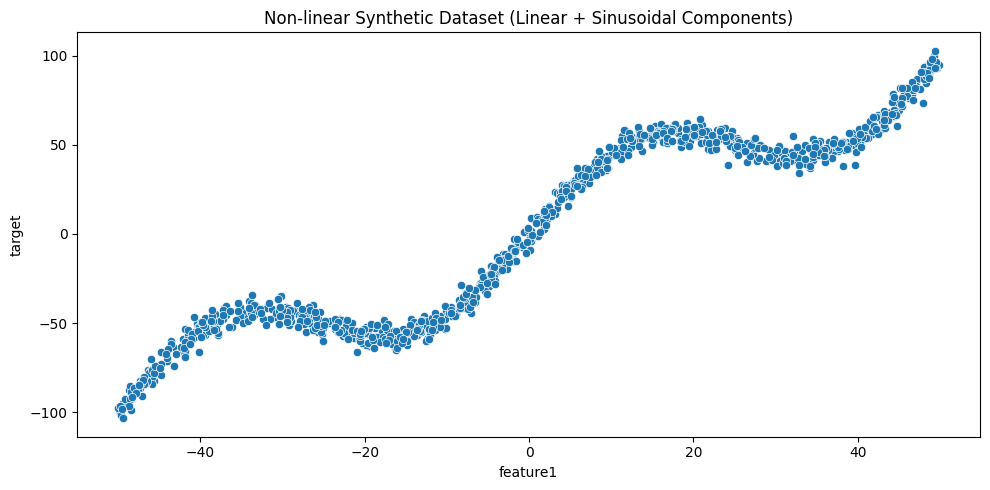

In [7]:
import seaborn as sns

np.random.seed(123)
n_samples = 1000
X_nl = np.random.uniform(-50, 50, (n_samples, 1))

# Non-linear target: linear + sinusoidal component + noise
y_nl = (2 * X_nl[:, 0]
        + 27 * np.sin(X_nl[:, 0] / 8)
        + np.random.normal(0, 4, n_samples))

data_nl = pd.DataFrame(X_nl, columns=['feature1'])
data_nl['target'] = y_nl

plt.figure(figsize=(10, 5))
sns.scatterplot(data=data_nl, x='feature1', y='target')
plt.title('Non-linear Synthetic Dataset (Linear + Sinusoidal Components)')
plt.tight_layout()
plt.show()


In [8]:
from sklearn.preprocessing import PolynomialFeatures

X_nl_feat = data_nl[['feature1']]
y_nl_tgt  = data_nl['target']
degrees   = [1, 2, 3, 4, 5]
results   = []

for degree in degrees:
    poly     = PolynomialFeatures(degree=degree)
    X_poly   = poly.fit_transform(X_nl_feat)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_poly, y_nl_tgt, test_size=0.2, random_state=123
    )
    poly_model = LinearRegression()
    poly_model.fit(X_tr, y_tr)
    y_hat = poly_model.predict(X_te)
    results.append({
        'Degree': degree,
        'MSE':    mean_squared_error(y_te, y_hat),
        'R2':     r2_score(y_te, y_hat)
    })

results_df = pd.DataFrame(results)
print("Polynomial Regression Performance by Degree:")
print(results_df.to_string(index=False))


Polynomial Regression Performance by Degree:
 Degree        MSE       R2
      1 317.005037 0.891135
      2 316.818454 0.891199
      3 268.477397 0.907800
      4 268.230101 0.907885
      5  48.316167 0.983407


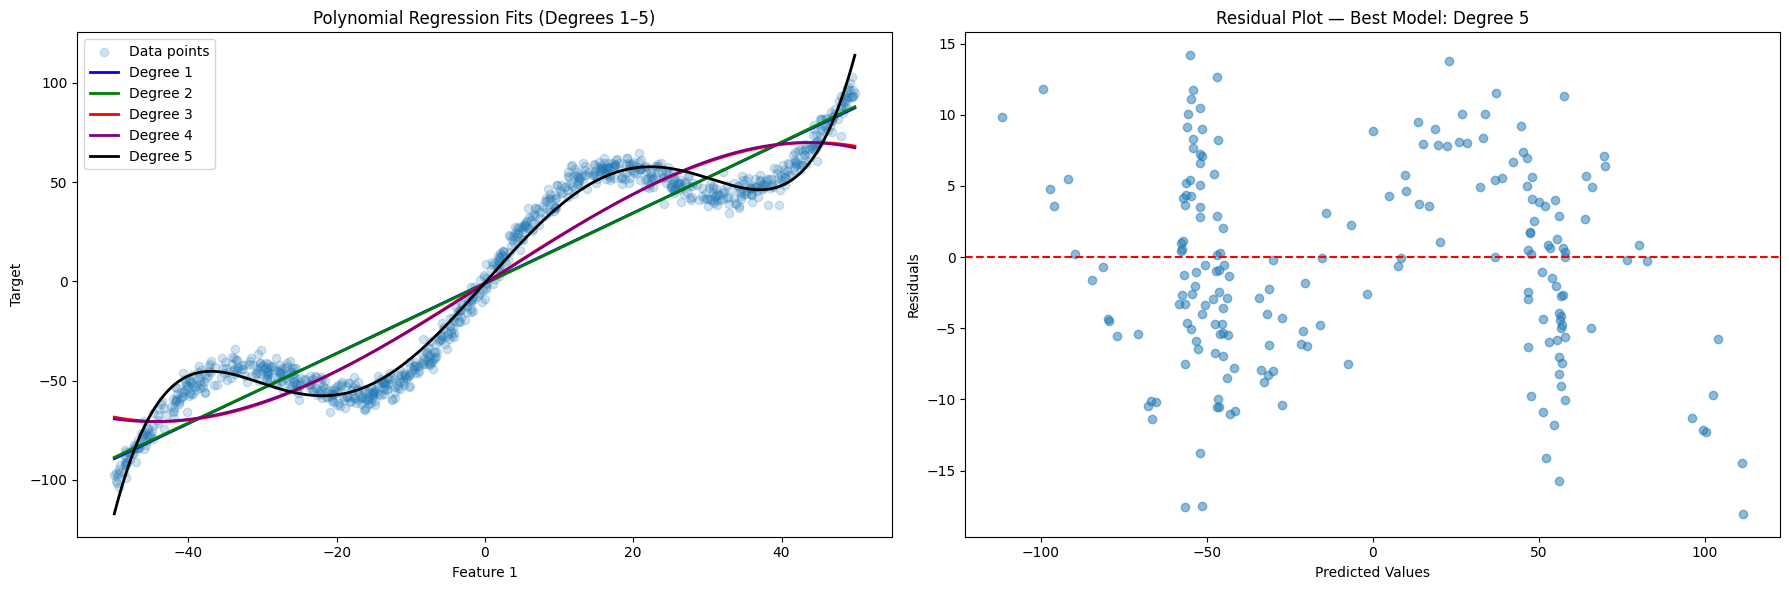

In [9]:
# Visual comparison of polynomial fits
X_plot_nl = np.linspace(
    X_nl_feat['feature1'].min(),
    X_nl_feat['feature1'].max(), 1000
).reshape(-1, 1)

colors_poly = ['blue', 'green', 'red', 'purple', 'black']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
ax1.scatter(X_nl_feat, y_nl_tgt, alpha=0.2, label='Data points')

for degree, color in zip(degrees, colors_poly):
    poly        = PolynomialFeatures(degree=degree)
    model_poly  = LinearRegression()
    model_poly.fit(poly.fit_transform(X_nl_feat), y_nl_tgt)
    y_plot      = model_poly.predict(poly.fit_transform(X_plot_nl))
    ax1.plot(X_plot_nl, y_plot, label=f'Degree {degree}', color=color, linewidth=2)

ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Target')
ax1.set_title('Polynomial Regression Fits (Degrees 1–5)')
ax1.legend(loc='upper left')

# Residual plot for the best degree (highest R²)
best_degree  = results_df.loc[results_df['R2'].idxmax(), 'Degree']
best_poly    = PolynomialFeatures(degree=best_degree)
X_poly_best  = best_poly.fit_transform(X_nl_feat)
X_tr, X_te, y_tr, y_te = train_test_split(X_poly_best, y_nl_tgt, test_size=0.2, random_state=123)
best_model   = LinearRegression()
best_model.fit(X_tr, y_tr)
y_pred_best  = best_model.predict(X_te)
residuals    = y_te - y_pred_best

ax2.scatter(y_pred_best, residuals, alpha=0.5)
ax2.axhline(y=0, color='r', linestyle='--')
ax2.set_xlabel('Predicted Values')
ax2.set_ylabel('Residuals')
ax2.set_title(f'Residual Plot — Best Model: Degree {best_degree}')

plt.tight_layout()
plt.show()


## **5.3 Spline Interpolation**

Spline interpolation partitions the feature space at **knot points** and fits a smooth polynomial (typically cubic, degree=3) to each segment. The `SplineTransformer` in scikit-learn handles the feature transformation step, which is then piped into `LinearRegression`.

The number of knots controls model flexibility — more knots allow the spline to track finer patterns in the data, though at the risk of overfitting.

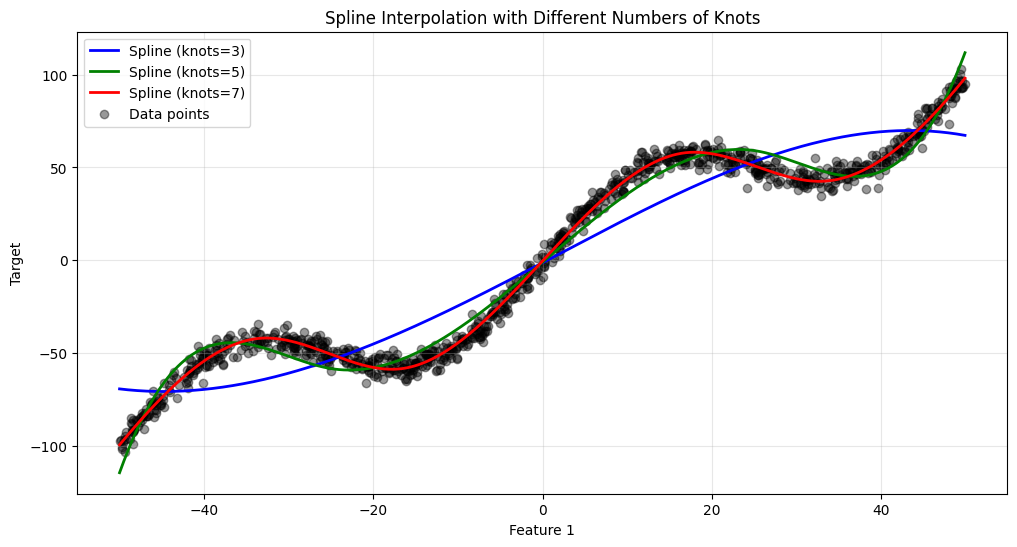


Spline Interpolation Performance by Knot Count:
 Knots        MSE       R2
     3 274.267019 0.904652
     5  55.347798 0.980759
     7  15.502097 0.994611


In [10]:
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline

n_knots_list = [3, 5, 7]
colors_spline = ['blue', 'green', 'red']
spline_metrics = []

plt.figure(figsize=(12, 6))

for n_knot, color in zip(n_knots_list, colors_spline):
    spline    = SplineTransformer(n_knots=n_knot, degree=3)
    model_sp  = make_pipeline(spline, LinearRegression())
    model_sp.fit(X_nl_feat, y_nl_tgt)

    y_pred_sp    = model_sp.predict(X_plot_nl)
    y_train_sp   = model_sp.predict(X_nl_feat)
    mse_sp       = mean_squared_error(y_nl_tgt, y_train_sp)
    r2_sp        = r2_score(y_nl_tgt, y_train_sp)
    spline_metrics.append({'Knots': n_knot, 'MSE': mse_sp, 'R2': r2_sp})

    plt.plot(X_plot_nl, y_pred_sp, label=f'Spline (knots={n_knot})', color=color, linewidth=2)

plt.scatter(X_nl_feat, y_nl_tgt, color='black', alpha=0.4, label='Data points')
plt.xlabel('Feature 1')
plt.ylabel('Target')
plt.title('Spline Interpolation with Different Numbers of Knots')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

spline_df = pd.DataFrame(spline_metrics)
print("\nSpline Interpolation Performance by Knot Count:")
print(spline_df.to_string(index=False))
